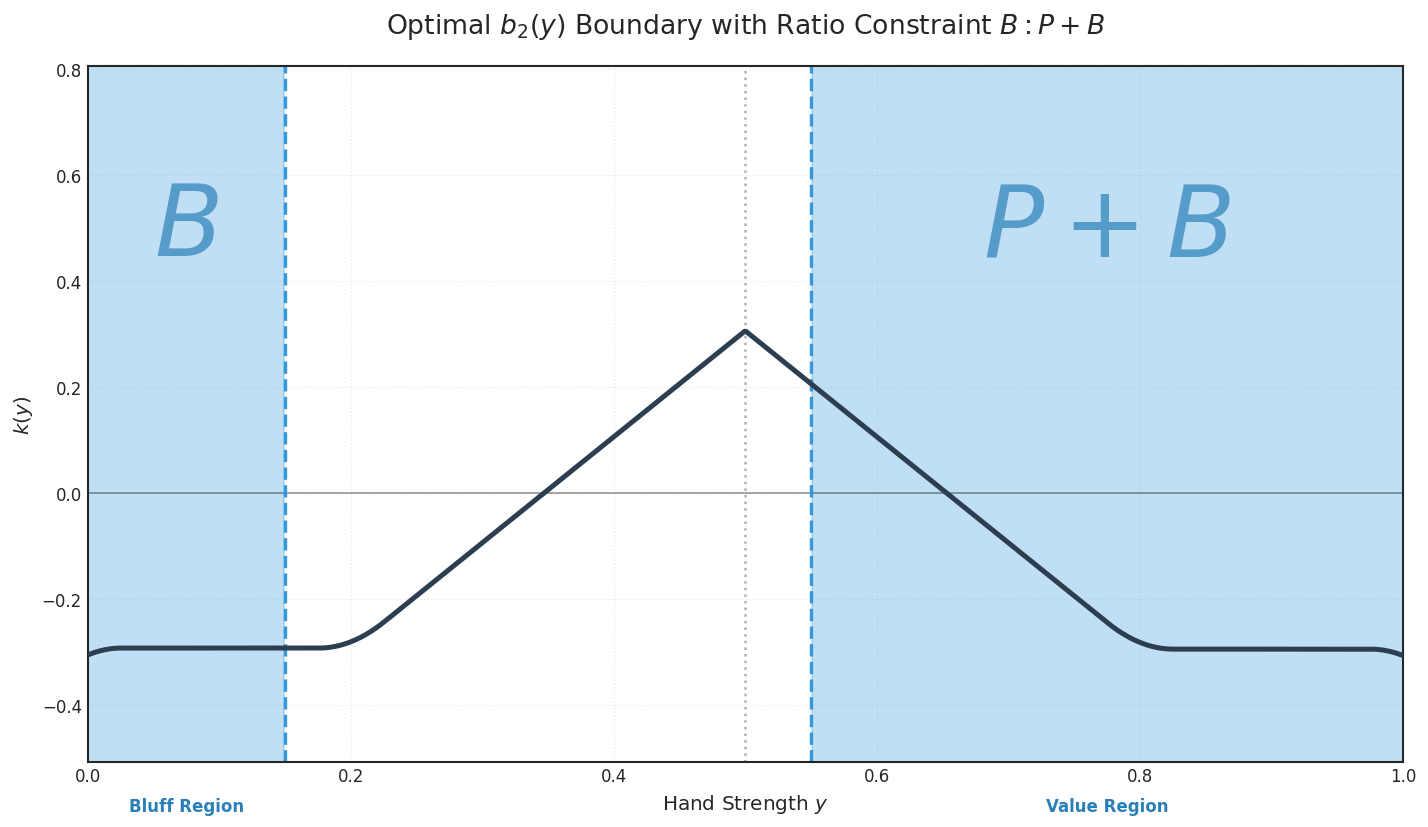

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 參數與比例設置
# ==========================================
P = 2.0  # 設定為整數
B = 1.0  # 設定為整數
lamda = 0.45  # 控制下注範圍縮放

# 確保 z1 : (1-z2) = B : P+B
ratio = B / (P + B)
z1 = lamda * ratio
z2 = 1 - lamda

# ==========================================
# 2. 數值模擬 (支援 a1 為數列)
# ==========================================
t = np.linspace(0, 1, 1000)
dt = t[1] - t[0]
x2_star = 0.5

# --- a1(x) 現在可以是任何數列 ---
# 這裡模擬一個極化的 a1(x)：強牌與弱牌下注，中間牌 Check
a1 = np.zeros_like(t)
a1[t < 0.2] = 1.0   # Bluff range
a1[t > 0.8] = 1.0   # Value range
# 平滑化處理 (可選)
a1 = np.convolve(a1, np.ones(50)/50, mode='same')

f_x = 1.0 - a1  # Player A Check 的密度

# 計算銜接點 k(x2*) = B * Integral_{x2*}^1 f(x) dx
k_at_x2 = B * np.sum(f_x[t >= x2_star]) * dt

# 根據微分方程構造 k(y)
k_y = np.zeros_like(t)

# 計算 k1 段 (0 到 0.5): k1'(y) = P * f(y)
# 使用 np.cumsum 來優化數列計算
k_y[:500] = k_at_x2 - P * np.flip(np.cumsum(np.flip(f_x[:500]))) * dt

# 計算 k2 段 (0.5 到 1.0): k2'(y) = -2B * f(y)
k_y[500:] = k_at_x2 - 2 * B * np.cumsum(f_x[500:]) * dt

# ==========================================
# 3. 繪圖
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)
plt.style.use('seaborn-v0_8-white')

# 畫出連續的 k(y)
ax.plot(t, k_y, color='#2c3e50', linewidth=3, label='$k(y)$', zorder=5)
ax.axhline(0, color='black', linewidth=1, alpha=0.4)
ax.axvline(x2_star, color='gray', linestyle=':', alpha=0.6)

# 填充 b2(y) 區域
blue_fill = '#3498db'
ax.fill_between(t, -2, 2, where=(t <= z1), color=blue_fill, alpha=0.3)
ax.fill_between(t, -2, 2, where=(t >= z2), color=blue_fill, alpha=0.3)
ax.axvline(z1, color=blue_fill, linestyle='--', linewidth=2)
ax.axvline(z2, color=blue_fill, linestyle='--', linewidth=2)

# ★★★ 標示大字體 B 與 P+B (Alpha=0.7, 整數) ★★★
# 標示 B
ax.text(z1 / 2, 0.5, f"$B$", 
        fontsize=60, ha='center', va='center', 
        color='#2980b9', fontweight='bold', alpha=0.7, zorder=10)

# 標示 P+B
ax.text(z2 + (1 - z2) / 2, 0.5, f"$P+B$", 
        fontsize=60, ha='center', va='center', 
        color='#2980b9', fontweight='bold', alpha=0.7, zorder=10)

# 輔助文字
ax.text(z1/2, -0.6, 'Bluff Region', color='#2980b9', ha='center', fontweight='bold')
ax.text(z2 + (1-z2)/2, -0.6, 'Value Region', color='#2980b9', ha='center', fontweight='bold')

# 設定標題與標籤
ax.set_title(r"Optimal $b_2(y)$ Boundary with Ratio Constraint $B : P+B$", fontsize=16, pad=20)
ax.set_xlim(0, 1)
ax.set_ylim(np.min(k_y) - 0.2, np.max(k_y) + 0.5)
ax.set_xlabel("Hand Strength $y$", fontsize=12)
ax.set_ylabel("$k(y)$", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

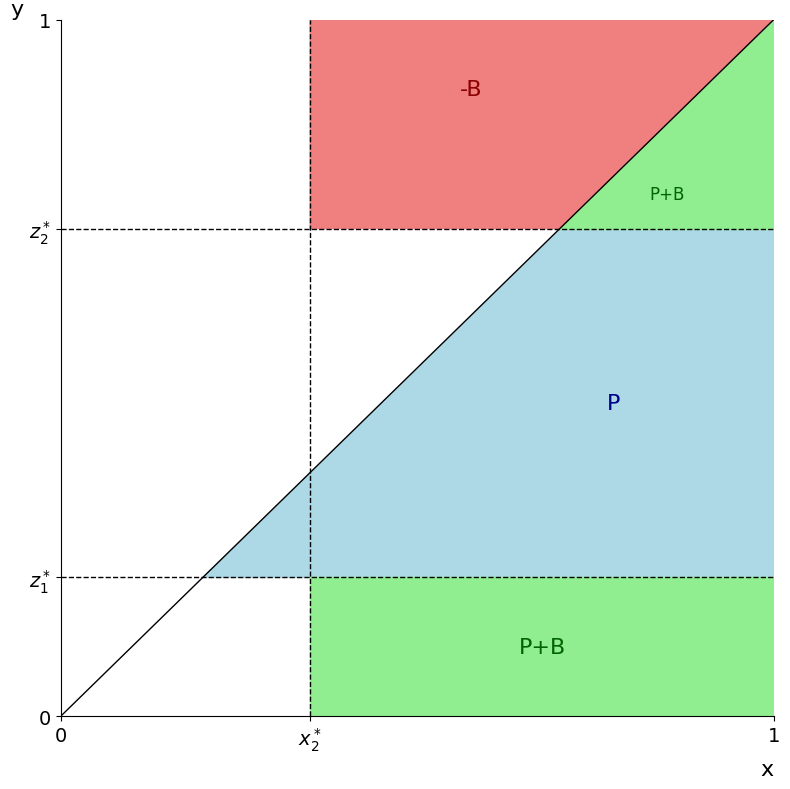

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os 

# === 1. 設定參數 ===
# 根據圖示邏輯設定相對位置： 0 < z1* < x2* < z2* < 1
Z1_STAR = 0.2
X2_STAR = 0.35
Z2_STAR = 0.7
XY_LIMIT = 1.0

# 建立畫布
fig, ax = plt.subplots(figsize=(8, 8))

# === 2. 定義顏色 ===
COLOR_MINUS_B = 'lightcoral'   # -B: 紅色系
COLOR_P = 'lightblue'          # P: 藍色系
COLOR_PB = 'lightgreen'        # P+B: 綠色系 (兩塊用同一色)

# === 3. 繪製區域 ===

# --- 區域 A: "-B" 區域 ---
# 條件: y > z2* (上方), x > x2* (右側), x < y (對角線上方)
# 形狀: 是一個被對角線切過的梯形/多邊形
# 頂點順序: (x2*, z2*) -> (z2*, z2*) -> (1, 1) -> (x2*, 1) -> 回到起點
ax.fill([X2_STAR, Z2_STAR, 1, X2_STAR], 
        [Z2_STAR, Z2_STAR, 1, 1],
        color=COLOR_MINUS_B, label='-B Region')
# 標籤
ax.text((X2_STAR + 1)/2 - 0.1, (Z2_STAR + 1)/2 + 0.05, '-B', 
        color='darkred', fontsize=16, ha='center', va='center')


# --- 區域 B: "P" 區域 ---
# 條件: z1* < y < z2* (中間), x > x2* (右側), x > y (對角線下方)
# 左邊界 logic: 在 y < x2* 的部分被 x=x2* 切，在 y > x2* 的部分被 y=x 切
# 頂點順序: (z1*, z1*) -> (1, z1*) -> (1, z2*) -> (z2*, z2*)  -> 回到起點
ax.fill([Z1_STAR, 1, 1, Z2_STAR], 
        [Z1_STAR, Z1_STAR, Z2_STAR, Z2_STAR],
        color=COLOR_P, label='P Region')
# 標籤
ax.text((X2_STAR + 1)/2 + 0.1, (Z1_STAR + Z2_STAR)/2, 'P', 
        color='darkblue', fontsize=16, ha='center', va='center')


# --- 區域 C1: 下方的 "P+B" 區域 ---
# 條件: y < z1* (下方), x > x2* (右側)
# 因為 z1* < x2*，所以在此區域恆有 x > y (對角線下方)
ax.fill([X2_STAR, 1, 1, X2_STAR], 
        [0, 0, Z1_STAR, Z1_STAR],
        color=COLOR_PB, label='P+B Region')
# 標籤
ax.text((X2_STAR + 1)/2, Z1_STAR/2, 'P+B', 
        color='darkgreen', fontsize=16, ha='center', va='center')


# --- 區域 C2: 右上角的 "P+B" 區域 (新增的部分) ---
# 條件: y > z2* (上方), x > y (對角線下方)
# 形狀: 三角形
ax.fill([Z2_STAR, 1, 1], 
        [Z2_STAR, Z2_STAR, 1],
        color=COLOR_PB) # 同色，不重複 label
# 標籤 (空間較小，字縮小一點)
ax.text(Z2_STAR + 0.15, Z2_STAR + 0.05, 'P+B', 
        color='darkgreen', fontsize=12, ha='center', va='center')


# === 4. 輔助線與裝飾 ===

# 畫對角線 y=x
ax.plot([0, 1], [0, 1], 'k-', linewidth=1)

# 畫閾值線 (虛線)
ax.axvline(x=X2_STAR, color='k', linestyle='--', linewidth=1)
ax.axhline(y=Z1_STAR, color='k', linestyle='--', linewidth=1)
ax.axhline(y=Z2_STAR, color='k', linestyle='--', linewidth=1)

# 座標軸設定
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 刻度標籤
ax.set_xticks([0, X2_STAR, 1])
ax.set_xticklabels(['0', r'$x_2^*$', '1'], fontsize=14)
ax.set_yticks([0, Z1_STAR, Z2_STAR, 1])
ax.set_yticklabels(['0', r'$z_1^*$', r'$z_2^*$', '1'], fontsize=14)

# 軸名稱
ax.set_xlabel('x', fontsize=16, loc='right')
ax.set_ylabel('y', fontsize=16, loc='top', rotation=0)

plt.tight_layout()
os.makedirs('images/lesson_7', exist_ok=True)
plt.savefig('images/lesson_7/integral_region_Jxy.png', dpi=300, bbox_inches='tight')
plt.show()

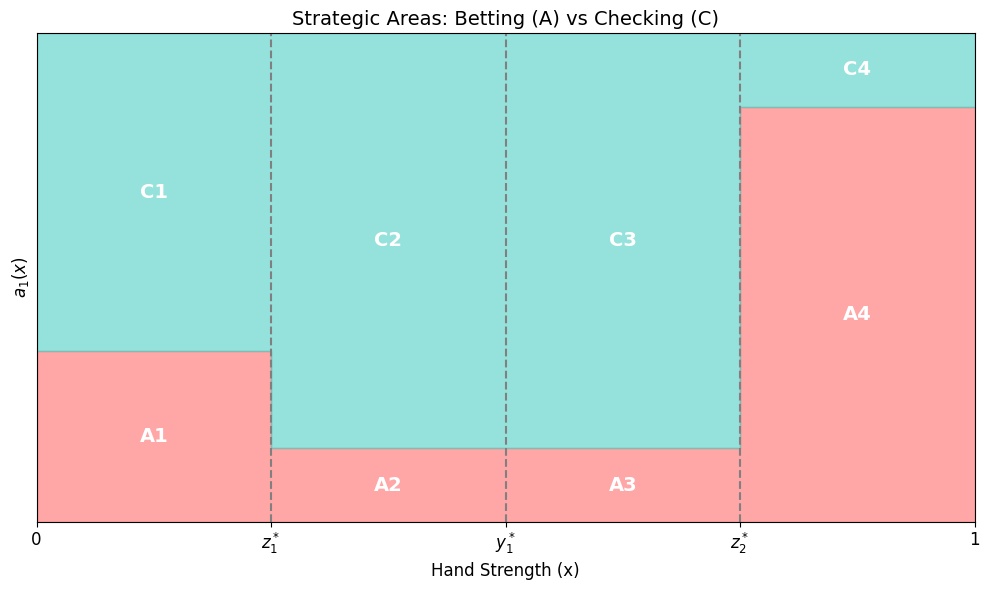

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def draw_strategy_schematic():
    # 1. 設定參數 (閾值與示意用的下注頻率)
    # 這些是 x 軸的切分點
    z1 = 0.25
    y1 = 0.50
    z2 = 0.75
    
    # 為了示意，我們為每個區間設定一個假想的「平均下注頻率 a1(x)」
    # 高度 (0到1之間) 代表該牌力下注的機率
    # 下面的數值可以根據你想呈現的賽局結構自由調整
    freq_1 = 0.35  # 區間 1 的下注頻率 (Bluff)
    freq_2 = 0.15  # 區間 2 的下注頻率
    freq_3 = 0.15  # 區間 3 的下注頻率
    freq_4 = 0.85  # 區間 4 的下注頻率 (Value)

    # 建立數據點用來畫階梯圖
    # 我們使用 step 函數的邏輯來構建 x 和 y
    x_points = [0, z1, z1, y1, y1, z2, z2, 1]
    y_bet    = [freq_1, freq_1, freq_2, freq_2, freq_3, freq_3, freq_4, freq_4]
    
    # y_top 固定為 1 (代表機率總和 100%)
    y_top = [1] * len(x_points)

    # 2. 開始繪圖
    fig, ax = plt.subplots(figsize=(10, 6))

    # 3. 上色：A 的部分 (下注)
    # 使用 fill_between 填充 y=0 到 y=bet_freq 之間的區域
    ax.fill_between(x_points, 0, y_bet, 
                    color='#FF6B6B', alpha=0.6, label='Bet Area (A)')

    # 4. 上色：C 的部分 (過牌)
    # 使用 fill_between 填充 y=bet_freq 到 y=1 之間的區域
    ax.fill_between(x_points, y_bet, y_top, 
                    color='#4ECDC4', alpha=0.6, label='Check Area (C)')

    # 5. 繪製分隔線與標示文字
    thresholds = [z1, y1, z2]
    threshold_labels = [r'$z_1^*$', r'$y_1^*$', r'$z_2^*$']
    
    # 畫垂直虛線
    for t in thresholds:
        ax.axvline(x=t, color='gray', linestyle='--', linewidth=1.5)

    # 在每個區塊的中心加上標籤 (A1-A4, C1-C4)
    # 定義每個區間的中心 x 和對應的 y
    regions = [
        (0, z1, freq_1, '1'),
        (z1, y1, freq_2, '2'),
        (y1, z2, freq_3, '3'),
        (z2, 1.0, freq_4, '4')
    ]

    for start, end, freq, idx in regions:
        mid_x = (start + end) / 2
        
        # 標示 A (下注區) - 放在紅色區塊中間
        ax.text(mid_x, freq / 2, f'A{idx}', 
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        
        # 標示 C (過牌區) - 放在青色區塊中間
        # 計算 C 區塊的中點: freq + (1 - freq)/2
        mid_y_c = freq + (1 - freq) / 2
        ax.text(mid_x, mid_y_c, f'C{idx}', 
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # 6. 設定圖表格式
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Hand Strength (x)', fontsize=12)
    ax.set_ylabel('$a_1(x)$', fontsize=12)
    ax.set_title('Strategic Areas: Betting (A) vs Checking (C)', fontsize=14)
    
    # 設定 X 軸刻度標籤
    ax.set_xticks([0, z1, y1, z2, 1])
    ax.set_xticklabels(['0', r'$z_1^*$', r'$y_1^*$', r'$z_2^*$', '1'], fontsize=12)
    
    # 隱藏 Y 軸刻度 (示意圖通常不需要具體機率值)
    ax.set_yticks([])
    
    # 加上圖例
    # ax.legend(loc='center right', frameon=True)

    plt.tight_layout()
    import os
    os.makedirs('images/lesson_7', exist_ok=True)
    plt.savefig('images/lesson_7/a1_area.png', dpi=300, bbox_inches='tight')
    plt.show()

# 執行繪圖函數
draw_strategy_schematic()

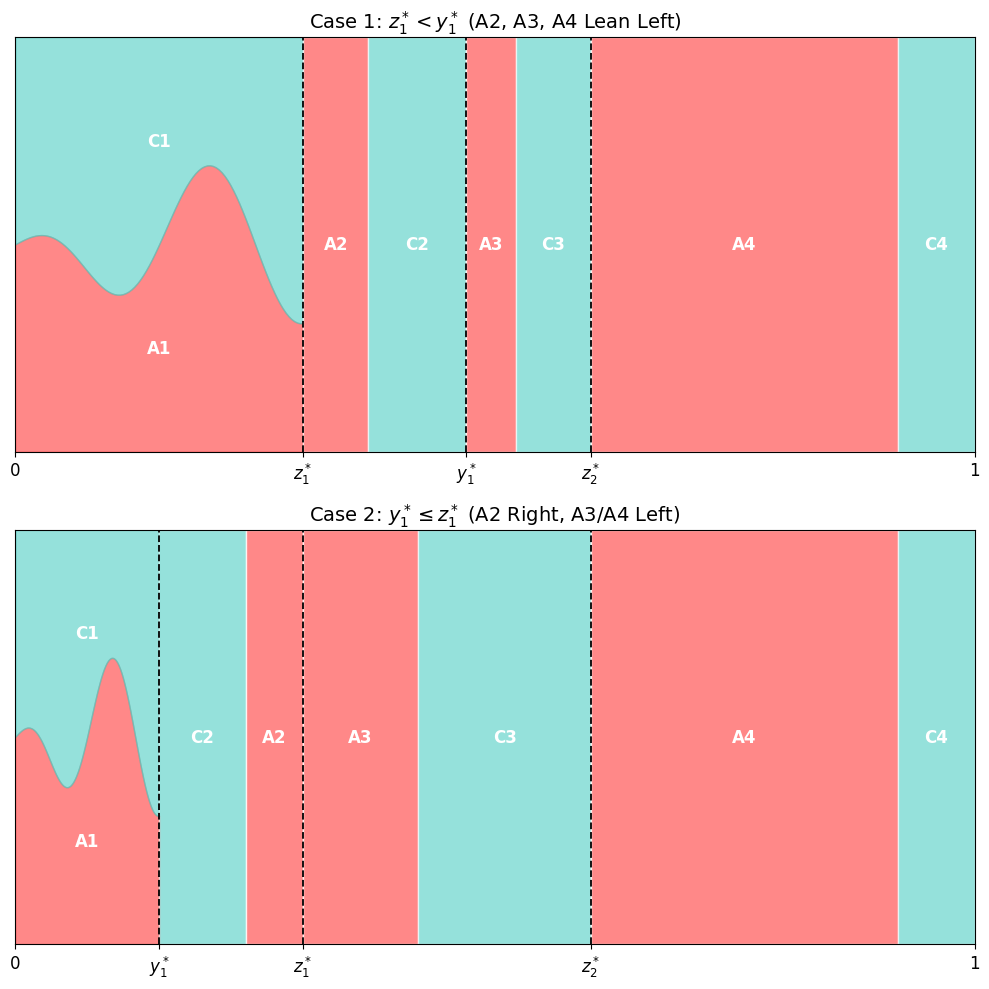

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_poker_strategy_comparison():
    # 設定圖表畫布 (兩張子圖：上下排列)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    # 顏色定義
    color_A = '#FF6B6B' # 下注色 (紅)
    color_C = '#4ECDC4' # 過牌色 (青)
    border_color = "#FFFFFF00"
    
    # 字體設定
    text_props = dict(ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    label_props = dict(ha='center', va='bottom', fontsize=10, color='black')

    # ==========================================
    # 輔助函式：繪製單一區間的 A/C 分佈
    # ==========================================
    def draw_interval(ax, x_start, x_end, a_freq, mode='left', label_idx='1'):
        width = x_end - x_start
        height = 1.0
        
        # 計算 A 和 C 的寬度
        w_a = width * a_freq
        w_c = width * (1 - a_freq)
        
        # 1. 特殊模式：Flat (波浪狀，用於 A1)
        if mode == 'flat':
            # 繪製 A1 (波浪水面)
            x_wave = np.linspace(x_start, x_end, 100)
            # 波浪高度在 0.3 ~ 0.7 之間擺盪
            y_wave = 0.5 + 0.2 * np.sin((x_wave - x_start) * 0.6 * np.pi / width) \
                            * np.cos((x_wave - x_start) * 3 * np.pi / width)
            
            # 填滿 A (下半部)
            ax.fill_between(x_wave, 0, y_wave, color=color_A, alpha=0.8)
            # 填滿 C (上半部)
            ax.fill_between(x_wave, y_wave, 1, color=color_C, alpha=0.6)
            
            # 標籤
            ax.text((x_start+x_end)/2, 0.25, f'A{label_idx}', **text_props)
            ax.text((x_start+x_end)/2, 0.75, f'C{label_idx}', **text_props)
            
        # 2. 一般模式：A 靠左 (Lean Left)
        elif mode == 'left':
            # A 在左邊
            rect_a = patches.Rectangle((x_start, 0), w_a, height, 
                                     facecolor=color_A, edgecolor=border_color, alpha=0.8)
            ax.add_patch(rect_a)
            # C 在右邊
            rect_c = patches.Rectangle((x_start + w_a, 0), w_c, height, 
                                     facecolor=color_C, edgecolor=border_color, alpha=0.6)
            ax.add_patch(rect_c)
            
            # 標籤 (若寬度太小則不標示以免重疊)
            if w_a > 0.05: ax.text(x_start + w_a/2, 0.5, f'A{label_idx}', **text_props)
            if w_c > 0.05: ax.text(x_start + w_a + w_c/2, 0.5, f'C{label_idx}', **text_props)

        # 3. 一般模式：A 靠右 (Lean Right)
        elif mode == 'right':
            # C 在左邊
            rect_c = patches.Rectangle((x_start, 0), w_c, height, 
                                     facecolor=color_C, edgecolor=border_color, alpha=0.6)
            ax.add_patch(rect_c)
            # A 在右邊
            rect_a = patches.Rectangle((x_start + w_c, 0), w_a, height, 
                                     facecolor=color_A, edgecolor=border_color, alpha=0.8)
            ax.add_patch(rect_a)
            
            # 標籤
            if w_c > 0.05: ax.text(x_start + w_c/2, 0.5, f'C{label_idx}', **text_props)
            if w_a > 0.05: ax.text(x_start + w_c + w_a/2, 0.5, f'A{label_idx}', **text_props)
        
        # 繪製區間分隔線
        if x_end < 1.0:
            ax.axvline(x=x_end, color='black', linestyle='--', linewidth=1.3)

    # ==========================================
    # 圖表 1: z1* < y1*
    # 邏輯：A1 Flat, 其餘 A 全部靠左 (C 全部靠右)
    # ==========================================
    ax = ax1
    z1, y1, z2 = 0.3, 0.47, 0.6
    
    # 繪製區塊
    draw_interval(ax, 0, z1,  0.5, 'flat', '1')   # A1 Flat
    draw_interval(ax, z1, y1, 0.4, 'left', '2')   # A2 Lean Left
    draw_interval(ax, y1, z2, 0.4, 'left', '3')   # A3 Lean Left
    draw_interval(ax, z2, 1.0, 0.8, 'left', '4')  # A4 Lean Left
    
    # 設定標題與軸
    ax.set_title(r'Case 1: $z_1^* < y_1^*$ (A2, A3, A4 Lean Left)', fontsize=14)
    ax.set_xticks([0, z1, y1, z2, 1])
    ax.set_xticklabels(['0', r'$z_1^*$', r'$y_1^*$', r'$z_2^*$', '1'], fontsize=12)
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # ==========================================
    # 圖表 2: y1* <= z1*
    # 邏輯：A1 Flat, A2 靠右, A3 A4 靠左
    # ==========================================
    ax = ax2
    # 這裡調整座標順序 y1 在 z1 前面
    y1_b, z1_b, z2_b = 0.15, 0.3, 0.6 
    
    # 繪製區塊
    draw_interval(ax, 0, y1_b,    0.5, 'flat',  '1')  # A1 Flat
    draw_interval(ax, y1_b, z1_b, 0.4, 'right', '2')  # A2 Lean Right (注意這裡!)
    draw_interval(ax, z1_b, z2_b, 0.4, 'left',  '3')  # A3 Lean Left
    draw_interval(ax, z2_b, 1.0,  0.8, 'left',  '4')  # A4 Lean Left
    
    # 設定標題與軸
    ax.set_title(r'Case 2: $y_1^* \leq z_1^*$ (A2 Right, A3/A4 Left)', fontsize=14)
    ax.set_xticks([0, y1_b, z1_b, z2_b, 1])
    ax.set_xticklabels(['0', r'$y_1^*$', r'$z_1^*$', r'$z_2^*$', '1'], fontsize=12)
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # 加入圖例 (Legend)
    # 建立假的 Patch 用於圖例
    # legend_elements = [
    #     patches.Patch(facecolor=color_A, edgecolor=border_color, label='Bet (A)'),
    #     patches.Patch(facecolor=color_C, edgecolor=border_color, label='Check (C)')
    # ]
    # fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=12)

    plt.tight_layout()
    import os
    os.makedirs('images/lesson_7', exist_ok=True)
    plt.savefig('images/lesson_7/two_cases_lean_tendency.png', dpi=300, bbox_inches='tight')
    plt.show()


draw_poker_strategy_comparison()

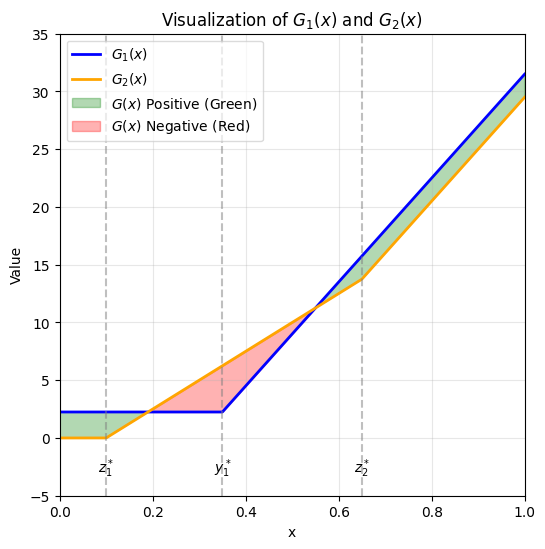

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_g1_g2():
    # 參數設定 (Parameters)
    P = 25.0
    B = 10.0
    # 設定 z1, y1, z2 使得圖形有兩個交點且最後重合
    # Derived condition for merge: y1 = 1 - z1(P/B + 2)
    z1 = 0.1
    y1 = 0.35 
    z2 = 1 - z1 * ((P+B)/B )
    
    # 定義 G1 函數
    def G1_func(x_val):
        if x_val <= y1:
            return (P + B) * y1 - B
        else:
            return (P + 2 * B) * x_val - B * (1 + y1)

    # 定義 G2 函數
    def G2_func(x_val):
        if x_val < z1:
            return 0.0
        elif z1 <= x_val <= z2:
            return P * (x_val - z1)
        else:
            # 注意：根據公式，此處會產生一個向上的跳躍以追上 G1
            return (P + 2 * B) * (x_val + z1) - 2 * B

    # 產生數據點
    x = np.linspace(0, 1.0, 1000)
    y_g1 = np.array([G1_func(val) for val in x])
    y_g2 = np.array([G2_func(val) for val in x])

    # 開始繪圖
    plt.figure(figsize=(6, 6))

    # 繪製線條
    plt.plot(x, y_g1, label=r'$G_1(x)$', color='blue', linewidth=2)
    plt.plot(x, y_g2, label=r'$G_2(x)$', color='orange', linewidth=2)

    # 填色區域 (Shading)
    # G1 > G2 塗綠色
    plt.fill_between(x, y_g1, y_g2, where=(y_g1 > y_g2), 
                     interpolate=True, color='green', alpha=0.3, label='$G(x)$ Positive (Green)')
    
    # G1 < G2 塗紅色 (負的部分)
    plt.fill_between(x, y_g1, y_g2, where=(y_g1 < y_g2), 
                     interpolate=True, color='red', alpha=0.3, label='$G(x)$ Negative (Red)')
    # 標記關鍵點 z1, y1, z2
    plt.axvline(z1, color='gray', linestyle='--', alpha=0.5)
    plt.text(z1, -3, r'$z_1^*$', ha='center', color='black')

    plt.axvline(y1, color='gray', linestyle='--', alpha=0.5)
    plt.text(y1, -3, r'$y_1^*$', ha='center', color='black')

    plt.axvline(z2, color='gray', linestyle='--', alpha=0.5)
    plt.text(z2, -3, r'$z_2^*$', ha='center', color='black')

    # 設定圖表標籤
    plt.title(r'Visualization of $G_1(x)$ and $G_2(x)$')
    plt.xlabel('x')
    plt.ylabel('Value')
    plt.legend(framealpha=0.7)
    plt.grid(True, alpha=0.3)
    
    # 顯示圖表
    plt.ylim(bottom=-5, top=35)
    plt.xlim(0, 1)
    import os
    os.makedirs('images/lesson_7', exist_ok=True)
    plt.savefig('images/lesson_7/G1_G2.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_g1_g2()

Image saved to images/lesson_7\a1_optimal.png


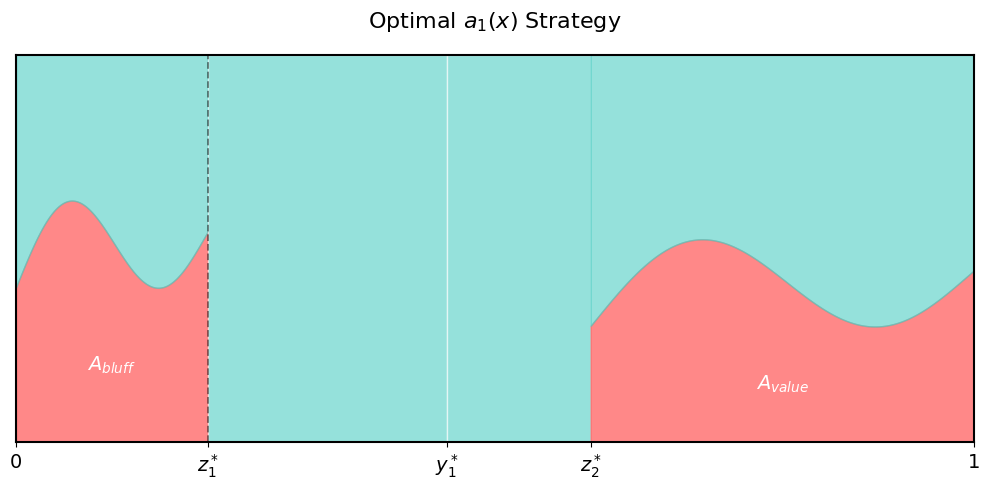

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os

def draw_specific_poker_strategy():
    # 設定圖表畫布 (單張圖)
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 顏色定義
    color_A = '#FF6B6B' # 下注色 (紅)
    color_C = '#4ECDC4' # 過牌色 (青)
    border_color = "#FFFFFF00"
    
    # 字體設定
    text_props = dict(ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # ==========================================
    # 輔助函式：繪製單一區間
    # 修改重點：
    # 1. 接收明確的 label 文字，而非索引 idx
    # 2. 不再繪製 C 部分的標籤
    # 3. 若 a_freq 為 0，則繪製純 C 區塊
    # ==========================================
    def draw_interval(ax, x_start, x_end, a_freq, mode='flat', label_a_text=None):
        width = x_end - x_start
        height = 1.0
        
        # 特殊情況：如果 A 的頻率為 0，則是純過牌區間
        if a_freq == 0:
            rect_c = patches.Rectangle((x_start, 0), width, height, 
                                     facecolor=color_C, edgecolor=border_color, alpha=0.6)
            ax.add_patch(rect_c)
            return # 結束此區間繪製

        # 模式：Flat (波浪狀，用於 A_bluff 和 A_value)
        if mode == 'flat':
            # 繪製波浪水面
            x_wave = np.linspace(x_start, x_end, 200)
            # 波浪高度計算，這裡稍微調整參數讓波浪在不同寬度下看起來自然些
            # freq_factor = 3.0 / width if width > 0 else 1
            y_wave = (1 - a_freq) + 0.15 * ( np.sin((x_wave - x_start) * 2 * np.pi / width) \
                                         + np.sin((x_wave - x_start) * 0.6 * np.pi / width) )
            
            # 確保波浪不超出邊界 0 和 1
            y_wave = np.clip(y_wave, 0.05, 0.95)

            # 填滿 A (下半部，紅色)
            ax.fill_between(x_wave, 0, y_wave, color=color_A, alpha=0.8)
            # 填滿 C (上半部，青色)
            ax.fill_between(x_wave, y_wave, 1, color=color_C, alpha=0.6)
            
            # 標籤 (只標示 A，且只有在有提供文字時才標示)
            if label_a_text:
                # 將文字放在稍微靠下的位置
                ax.text((x_start+x_end)/2, (1-a_freq)/2, label_a_text, **text_props)
            
            # 根據要求，不標示 C 的文字

        # 繪製區間分隔線
        if x_end < 1.0:
            ax.axvline(x=x_end, color='black', linestyle='--', linewidth=1.3, alpha=0.5)

    # ==========================================
    # 主要繪圖邏輯
    # 設定座標滿足 z1 < y1 < z2
    # ==========================================
    z1, y1, z2 = 0.2, 0.45, 0.6
    
    # 1. 區間 [0, z1]: A_bluff (波浪狀)
    draw_interval(ax, 0, z1, a_freq=0.6, mode='flat', label_a_text=r'$A_{bluff}$')
    
    # 2. 區間 [z1, y1]: 純過牌 (A頻率為 0)
    draw_interval(ax, z1, y1, a_freq=0, mode='none')
    
    # 3. 區間 [y1, z2]: 純過牌 (A頻率為 0)
    draw_interval(ax, y1, z2, a_freq=0, mode='none')
    
    # 4. 區間 [z2, 1]: A_value (波浪狀，要求改成跟A1一樣)
    draw_interval(ax, z2, 1.0, a_freq=0.7, mode='flat', label_a_text=r'$A_{value}$')
    
    # ==========================================
    # 設定標題與軸
    # ==========================================
    ax.set_title(r'Optimal $a_1(x)$ Strategy', fontsize=16, pad=20)
    ax.set_xticks([0, z1, y1, z2, 1])
    ax.set_xticklabels(['0', r'$z_1^*$', r'$y_1^*$', r'$z_2^*$', '1'], fontsize=14)
    ax.set_yticks([]) # 隱藏 Y 軸刻度
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # 加個外框讓圖看起來更完整
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    
    # 存檔設定
    save_dir = 'images/lesson_7'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'a1_optimal.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Image saved to {save_path}")
    plt.show()

if __name__ == '__main__':
    draw_specific_poker_strategy()